In [1]:
import pandas  as pd 
energy_data=pd.read_csv('AEP_hourly.csv')
print(energy_data.head(10))
energy_data.info()

              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0
5  2004-12-31 06:00:00  13038.0
6  2004-12-31 07:00:00  13692.0
7  2004-12-31 08:00:00  14297.0
8  2004-12-31 09:00:00  14719.0
9  2004-12-31 10:00:00  14941.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [2]:
energy_data['Datetime']=pd.to_datetime(energy_data['Datetime'])
energy_data.info('Datetime')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[ns]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.9 MB


In [3]:
energy_data.set_index('Datetime', inplace=True)  # Use Datetime as the dataframe index for easier data manipulation
energy_data.head(5)

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


In [4]:
# Sort the index to ensure chronological order for Prophet
energy_data.sort_index(inplace=True)
energy_data

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0
...,...
2018-08-02 20:00:00,17673.0
2018-08-02 21:00:00,17303.0
2018-08-02 22:00:00,17001.0


<Axes: xlabel='Datetime'>

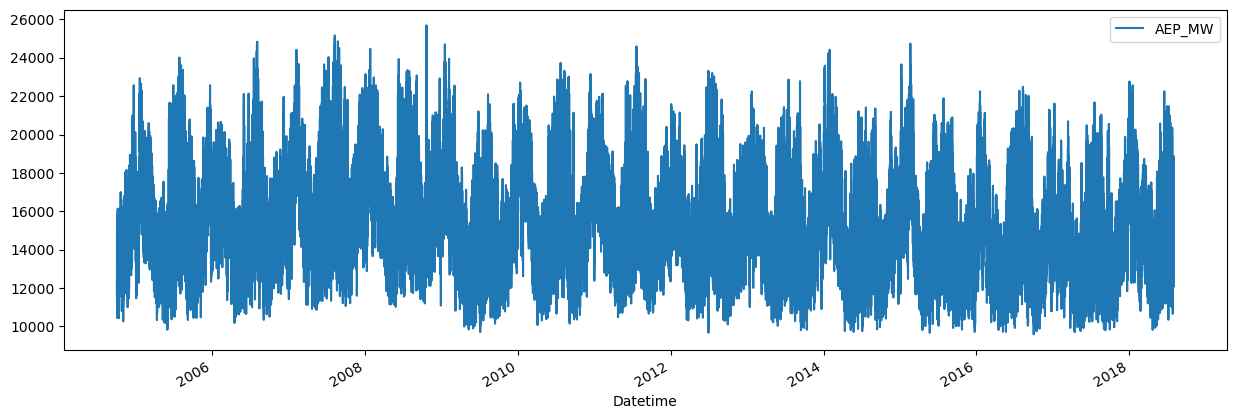

In [5]:
energy_data.plot(figsize=(15, 5))

In [6]:
#Let's calculate the time difference between each line
saat_ferqi = energy_data.index.to_series().diff()
#we are checking for any gaps larger than 1 hour to find missing data
bosluq=saat_ferqi[saat_ferqi>pd.Timedelta('1h')]
print("Tapılan boşluqların sayı:", len(bosluq))
print(bosluq)

Tapılan boşluqların sayı: 27
Datetime
2004-10-31 03:00:00   0 days 02:00:00
2005-04-03 04:00:00   0 days 02:00:00
2005-10-30 03:00:00   0 days 02:00:00
2006-04-02 04:00:00   0 days 02:00:00
2006-10-29 03:00:00   0 days 02:00:00
2007-03-11 04:00:00   0 days 02:00:00
2007-11-04 03:00:00   0 days 02:00:00
2008-03-09 04:00:00   0 days 02:00:00
2008-11-02 03:00:00   0 days 02:00:00
2009-03-08 04:00:00   0 days 02:00:00
2009-11-01 03:00:00   0 days 02:00:00
2010-03-14 04:00:00   0 days 02:00:00
2010-11-07 03:00:00   0 days 02:00:00
2010-12-10 01:00:00   0 days 02:00:00
2011-03-13 04:00:00   0 days 02:00:00
2011-11-06 03:00:00   0 days 02:00:00
2012-03-11 04:00:00   0 days 02:00:00
2012-11-04 03:00:00   0 days 02:00:00
2012-12-06 05:00:00   0 days 02:00:00
2013-03-10 04:00:00   0 days 02:00:00
2013-11-03 03:00:00   0 days 02:00:00
2014-03-09 04:00:00   0 days 02:00:00
2014-03-11 15:00:00   0 days 02:00:00
2015-03-08 04:00:00   0 days 02:00:00
2016-03-13 04:00:00   0 days 02:00:00
2017-03-12 0

In [7]:
# First, let's fill the gaps by resampling the data to hourly frequency
# We use 'ffill' to carry the last valid observation forward to the next valid
# We need to remove duplicate timestamps before resampling
energy_data = energy_data[~energy_data.index.duplicated(keep='first')]
energy_data= energy_data.resample('h').ffill()
# Now, we verify if there are any gaps left by checking the time difference again
# After resampling, the difference between all rows should be exactly 1 hour
bosluqlari_yoxla=energy_data.index.to_series().diff()
print(f"Təmizləndikdən sonra qalan boşluqlar: {len(bosluqlari_yoxla[bosluqlari_yoxla>pd.Timedelta('1h')])}")

Təmizləndikdən sonra qalan boşluqlar: 0


In [8]:
# Let's reset the index to bring 'Datetime' back as a regular column
energy_data_final = energy_data.reset_index()
# Now, we rename the columns to 'ds' and 'y' as required by Prophet
energy_data_final.columns = ['ds', 'y']
energy_data_final.head()

,ds,y
0,2004-10-01 01:00:00,12379.0
1,2004-10-01 02:00:00,11935.0
2,2004-10-01 03:00:00,11692.0
3,2004-10-01 04:00:00,11597.0
4,2004-10-01 05:00:00,11681.0


In [9]:
!pip install prophet

In [10]:
from prophet import Prophet

In [11]:
model=Prophet()
model.fit(energy_data_final)

22:55:01 - cmdstanpy - INFO - Chain [1] start processing
22:58:54 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
# let's create future dataframe for the next 365days 
#we use bevause periods=365 to tell the model how far we want predict
gelecek=model.make_future_dataframe(periods=365*25,freq='h')
forecast=model.predict(gelecek)
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
130416,2019-08-18 01:00:00,13300.949946,10260.065382,16220.126217
130417,2019-08-18 02:00:00,12714.218996,9647.242005,15542.964095
130418,2019-08-18 03:00:00,12377.136826,9245.044322,15455.194283
130419,2019-08-18 04:00:00,12337.650349,9222.839594,15438.514397
130420,2019-08-18 05:00:00,12628.922735,9530.329911,15601.097257


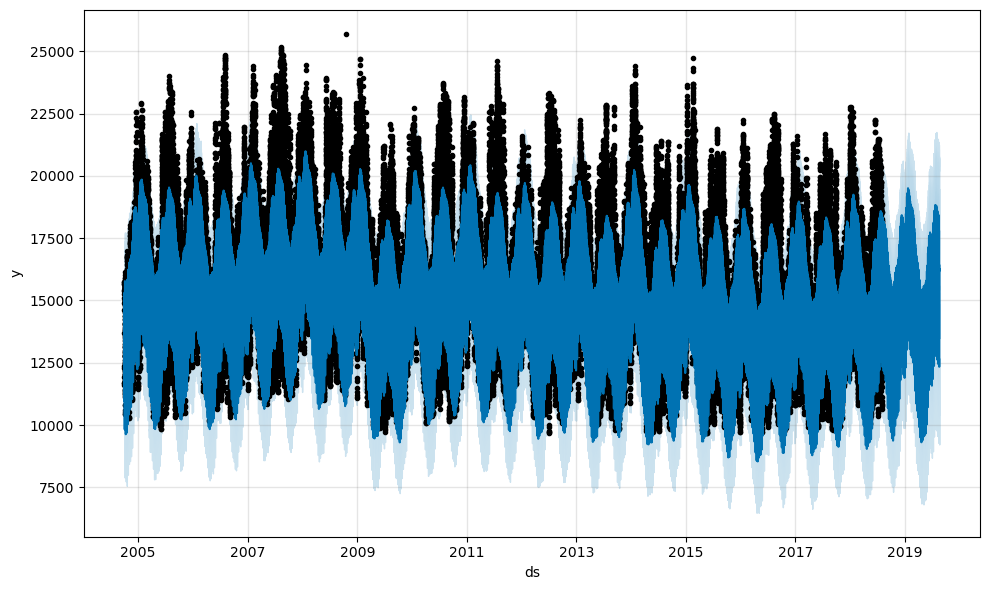

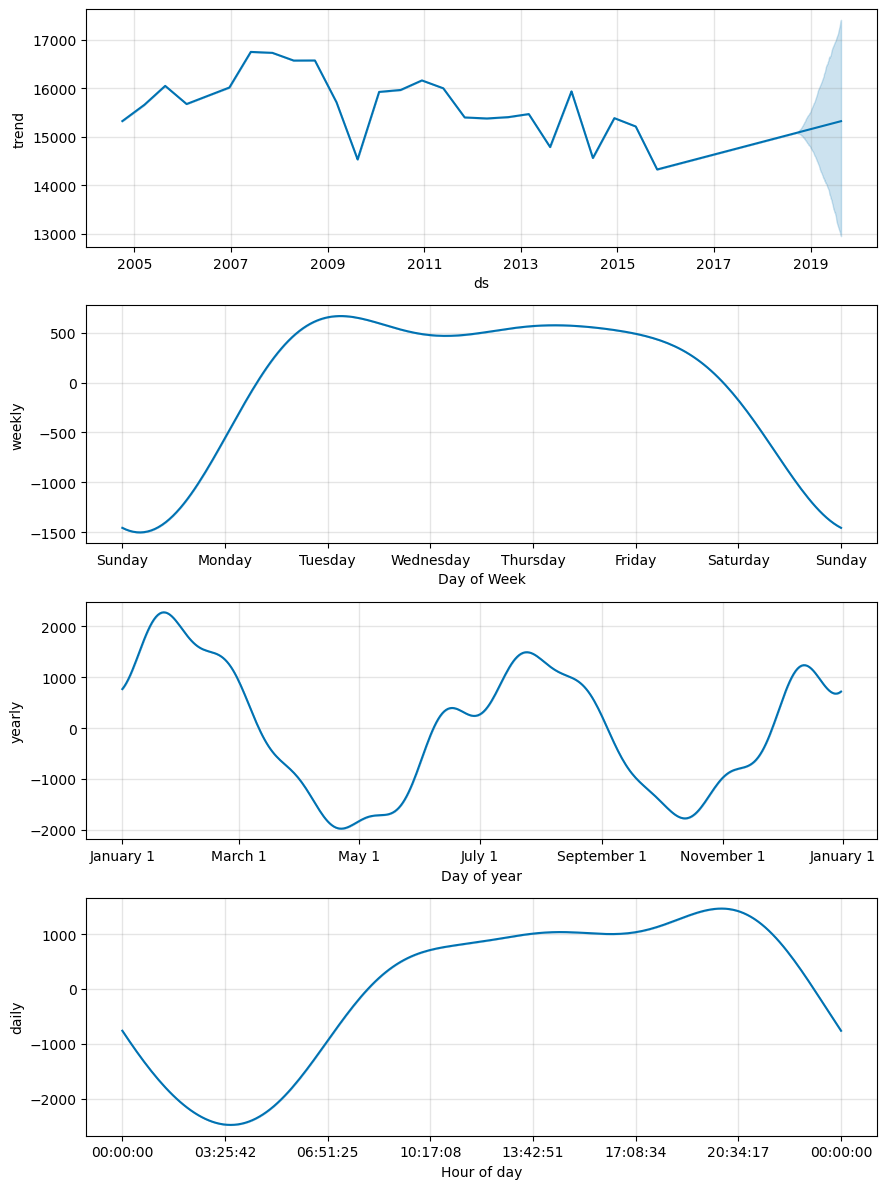

In [13]:
fig1=model.plot(forecast)
fig2=model.plot_components(forecast)


In [14]:
neticeler=energy_data_final.merge(forecast[['ds','yhat']],on='ds')
# We calculate the 'residuals' (the parts that Prophet couldn't predict correctly)
neticeler['residuals']=neticeler['y']-neticeler['yhat']
neticeler.head()

,ds,y,yhat,residuals
0,2004-10-01 01:00:00,12379.0,12819.221337,-440.221337
1,2004-10-01 02:00:00,11935.0,12235.778867,-300.778867
2,2004-10-01 03:00:00,11692.0,11895.690488,-203.690488
3,2004-10-01 04:00:00,11597.0,11846.678395,-249.678395
4,2004-10-01 05:00:00,11681.0,12121.710428,-440.710428


In [15]:
def create_features(df):
    df = df.copy()
    df['hour']=df['ds'].dt.hour
    df['dayofweek']=df['ds'].dt.dayofweek
    df['quarter']=df['ds'].dt.quarter
    df['month']=df['ds'].dt.month
    df['year']=df['ds'].dt.year
    df['dayofyear']=df['ds'].dt.dayofyear
    return df
# Let's apply this to our results dataframe
results_with_features = create_features(neticeler )

In [16]:
import xgboost as xgb
# Define our features and target
FEATURES=['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
TARGET='residuals'
X_train=results_with_features[FEATURES]
y_train=results_with_features[TARGET]
# Let's initialize and train the XGBoost regressor
# We use some standard parameters to start with
xgb_model=xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.01)
xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train)], verbose=100)

[0]	validation_0-rmse:1561.92903
[100]	validation_0-rmse:1428.36987
[200]	validation_0-rmse:1330.73696
[300]	validation_0-rmse:1251.03447
[400]	validation_0-rmse:1197.42527
[500]	validation_0-rmse:1144.83407
[600]	validation_0-rmse:1113.27659
[700]	validation_0-rmse:1088.15802
[800]	validation_0-rmse:1059.08242
[900]	validation_0-rmse:1031.64686
[999]	validation_0-rmse:1006.36377


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [17]:
# XGBoost predicts the 'error' Prophet might make
results_with_features['xgb_correction'] = xgb_model.predict(X_train)
# Final Hybrid Prediction = Prophet + XGBoost correction
results_with_features['y_hybrid'] = results_with_features['yhat'] + results_with_features['xgb_correction']

In [18]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
mae = mean_absolute_error(results_with_features['y'], results_with_features['y_hybrid'])
mape = mean_absolute_percentage_error(results_with_features['y'], results_with_features['y_hybrid'])
print(f"Hybrid Model MAE: {mae}")
print(f"Hybrid Model MAPE: {mape * 100:.2f}%")

Hybrid Model MAE: 766.8764774501838
Hybrid Model MAPE: 4.90%
